# Telco Customer Churn — Analysis Notebook
Predicting and understanding customer churn using a Decision Tree and Logistic Regression.

**Dataset:** WA_Fn-UseC_-Telco-Customer-Churn.csv (7,043 customers, 21 attributes)

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning

In [3]:
# TotalCharges is stored as text and has some blank values for brand-new customers (tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Rows with blank TotalCharges (new customers, tenure=0):", df['TotalCharges'].isnull().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.drop(columns=['customerID'], inplace=True)

churn_rate = (df['Churn'] == 'Yes').mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Rows with blank TotalCharges (new customers, tenure=0): 11
Overall churn rate: 26.54%


## 3. Exploratory Data Analysis
Which features correlate with churn?

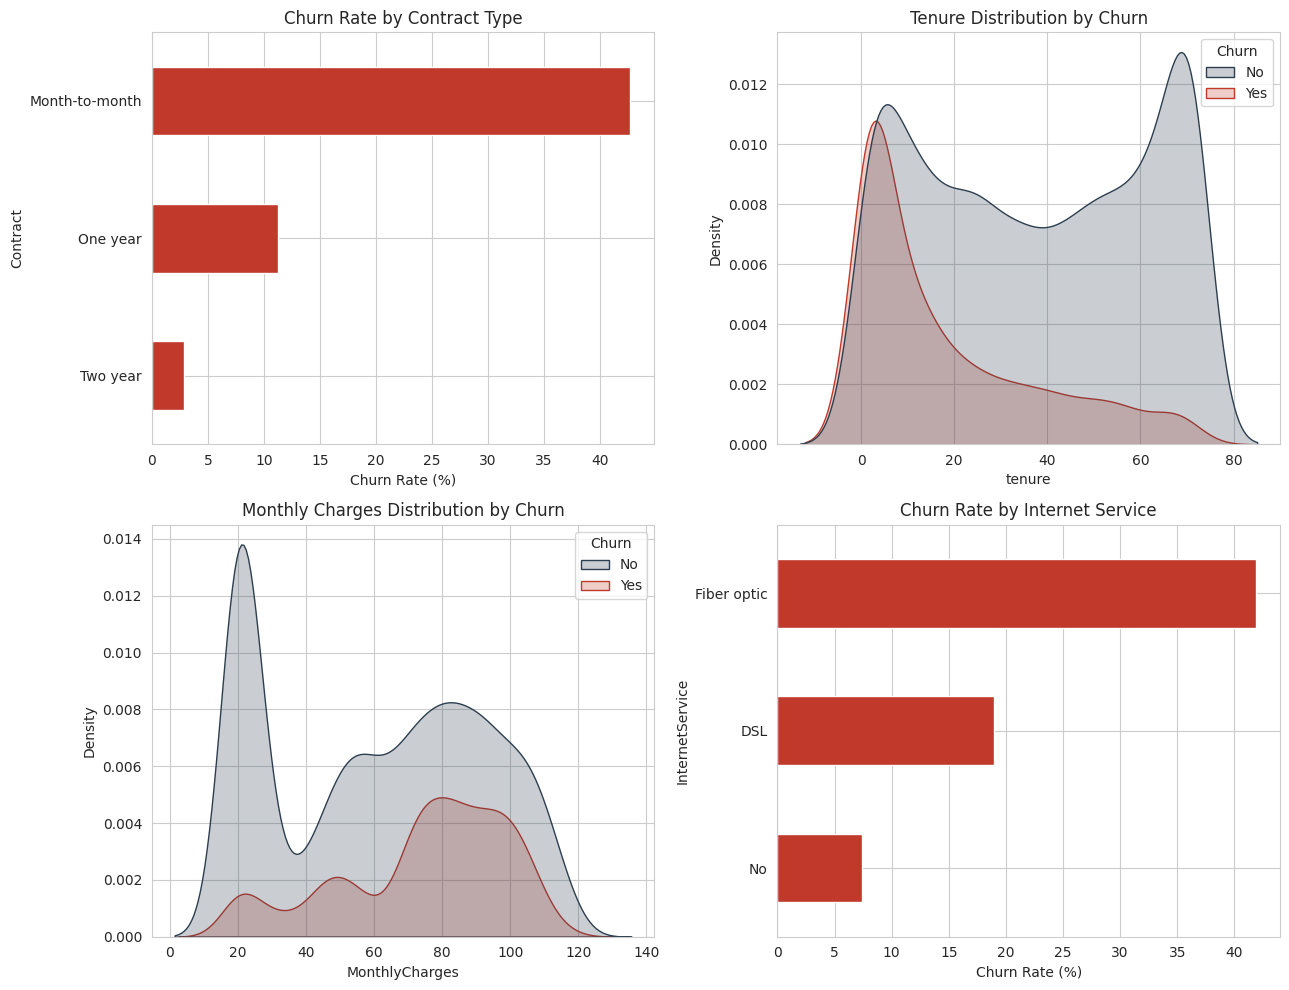

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Churn by contract type
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct['Yes'].sort_values().plot(kind='barh', ax=axes[0,0], color='#c0392b')
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_xlabel('Churn Rate (%)')

# Tenure distribution by churn
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=axes[0,1], palette=['#2c3e50','#c0392b'])
axes[0,1].set_title('Tenure Distribution by Churn')

# Monthly charges by churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1,0], palette=['#2c3e50','#c0392b'])
axes[1,0].set_title('Monthly Charges Distribution by Churn')

# Churn by internet service
it = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
it['Yes'].sort_values().plot(kind='barh', ax=axes[1,1], color='#c0392b')
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [5]:
# Correlation of numeric fields with churn
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)
num_corr = df_corr[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn_bin']].corr()['Churn_bin'].sort_values()
print("Correlation with churn (numeric features):")
num_corr

Correlation with churn (numeric features):


tenure           -0.352229
TotalCharges     -0.198324
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn_bin         1.000000
Name: Churn_bin, dtype: float64

**EDA takeaways:**
- **Contract type** is the strongest visual signal: month-to-month churn (~42%) is roughly 4x one-year and 15x two-year contracts.
- **Tenure**: churners are concentrated in the first ~12 months; customers past 2 years rarely leave.
- **Monthly charges**: churners skew toward higher bills ($70–$100 range), consistent with Fiber Optic customers.
- **Internet service**: Fiber Optic customers churn at over 40%, more than double DSL.

## 4. Encoding Categorical Variables & Class Imbalance

In [6]:
# Encode all categorical (object/string) columns with LabelEncoder
df_model = df.copy()
target = (df_model['Churn'] == 'Yes').astype(int)
df_model.drop(columns=['Churn'], inplace=True)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le_dict = {}
df_encoded = df_model.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

X = df_encoded
y = target
print(f"Encoded {len(cat_cols)} categorical columns: {cat_cols}")

Encoded 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_673/4028341233.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")
print(f"Class imbalance -> No: {sum(y==0)}, Yes: {sum(y==1)}  (ratio {sum(y==0)/sum(y==1):.2f}:1)")

Train churn rate: 26.54%, Test churn rate: 26.54%
Class imbalance -> No: 5174, Yes: 1869  (ratio 2.77:1)


**Class imbalance note:** Churners make up only 26.5% of customers (~2.8:1 imbalance). Left untreated, a
model can hit ~73% accuracy by simply predicting "No Churn" for everyone — while missing every real churner.
We mitigate this here with `class_weight='balanced'` in both models, which up-weights the minority class during
training. This is a reasonable first pass; a production version should also test **SMOTE oversampling** or
**threshold tuning** to balance precision/recall against the real business cost of a missed churner vs. a false alarm.

## 5. Train Models

In [8]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

In [9]:
# Logistic Regression (needs scaled features)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]

## 6. Model Comparison

In [10]:
def eval_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }

results = pd.DataFrame([
    eval_model('Decision Tree', y_test, dt_pred, dt_proba),
    eval_model('Logistic Regression', y_test, lr_pred, lr_proba),
])
results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.762243,0.539877,0.705882,0.611819,0.817430
1,Logistic Regression,0.738822,0.505085,0.796791,0.618257,0.839787


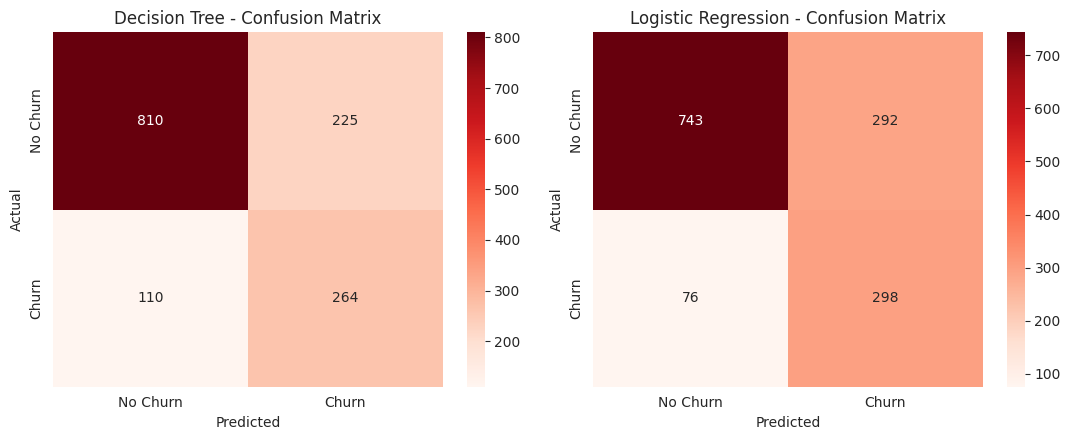

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [('Decision Tree', dt_pred), ('Logistic Regression', lr_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Takeaway:** Both models perform similarly overall. Logistic Regression edges out the Decision Tree on
recall and ROC-AUC — it catches more true churners (79.7% vs 70.6%) — at the cost of slightly more false alarms.
The Decision Tree is easier to explain in plain language ("if contract = month-to-month and no online security,
flag as at risk"), which matters when presenting to non-technical stakeholders.

## 7. Feature Importance (Decision Tree)

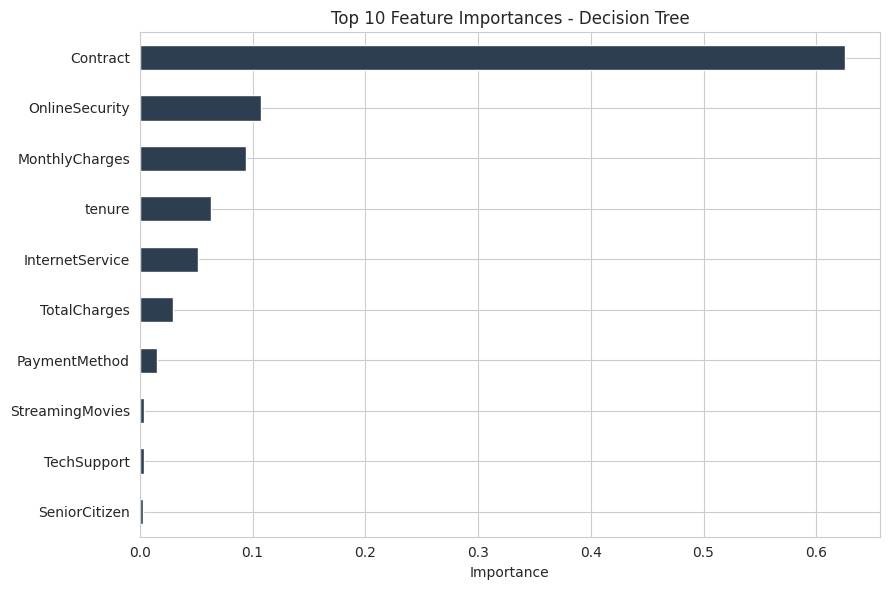

TOP 3 FEATURES DRIVING CHURN:
  Contract: 0.625
  OnlineSecurity: 0.107
  MonthlyCharges: 0.095


In [12]:
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.head(10).sort_values().plot(kind='barh', color='#2c3e50')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("TOP 3 FEATURES DRIVING CHURN:")
for feat, imp in importances.head(3).items():
    print(f"  {feat}: {imp:.3f}")

In [13]:
# Cross-check with Logistic Regression coefficients
lr_coef = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Top 10 Logistic Regression coefficients (by magnitude):")
lr_coef.head(10)

Top 10 Logistic Regression coefficients (by magnitude):


tenure             -1.112311
MonthlyCharges      0.733642
Contract           -0.633095
TotalCharges        0.439701
PhoneService       -0.285923
OnlineSecurity     -0.246534
TechSupport        -0.220288
PaperlessBilling    0.179345
InternetService     0.161489
OnlineBackup       -0.128309
dtype: float64

**Top 3 churn drivers:**
1. **Contract Type** (62.5%) — month-to-month customers churn far more than 1- or 2-year contract holders
2. **Online Security** (10.7%) — customers without this add-on churn at a much higher rate
3. **Monthly Charges** (9.5%) — higher bills correlate with a higher likelihood of leaving

Logistic Regression's coefficients tell a consistent story (tenure, Monthly Charges, Contract dominate), cross-validating the tree's findings from a different angle.

## 8. Business Summary

Roughly 1 in 4 customers (26.5%) in our sample churned, and the single biggest driver by far is **contract type**:
month-to-month customers churn at over 42%, compared to just 11% for one-year and under 3% for two-year contracts.
Customers without add-on services like Online Security, and those paying higher monthly bills, are also
significantly more likely to leave. We built two models to flag at-risk customers: a **Decision Tree** (76%
accuracy, easy to explain to any team) and a **Logistic Regression** model (74% accuracy, slightly better at
catching churners). Because churners are a minority of customers, we prioritized catching more true churners
(recall) over pure accuracy, since missing an at-risk customer is more costly than a false alarm. The clear
business takeaway: **incentivizing longer contracts and bundling security/support services are the
highest-leverage levers to reduce churn.**

**Recommended next steps:**
- Target month-to-month customers with incentives to migrate to 1- or 2-year contracts.
- Bundle Online Security and Tech Support into standard packages, especially for Fiber Optic customers.
- Build an early-warning score using the Logistic Regression model to flag high-risk customers within their first 90 days.
- Revisit pricing tiers for high Monthly Charges customers on month-to-month plans, the highest-risk segment in the data.